In [71]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import mutual_info_classif
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")

In [72]:
df=pd.read_csv('sleep_health_dataset.csv')

In [73]:
df = df.drop(["person_id","cognitive_performance_score","felt_rested"], axis=1)

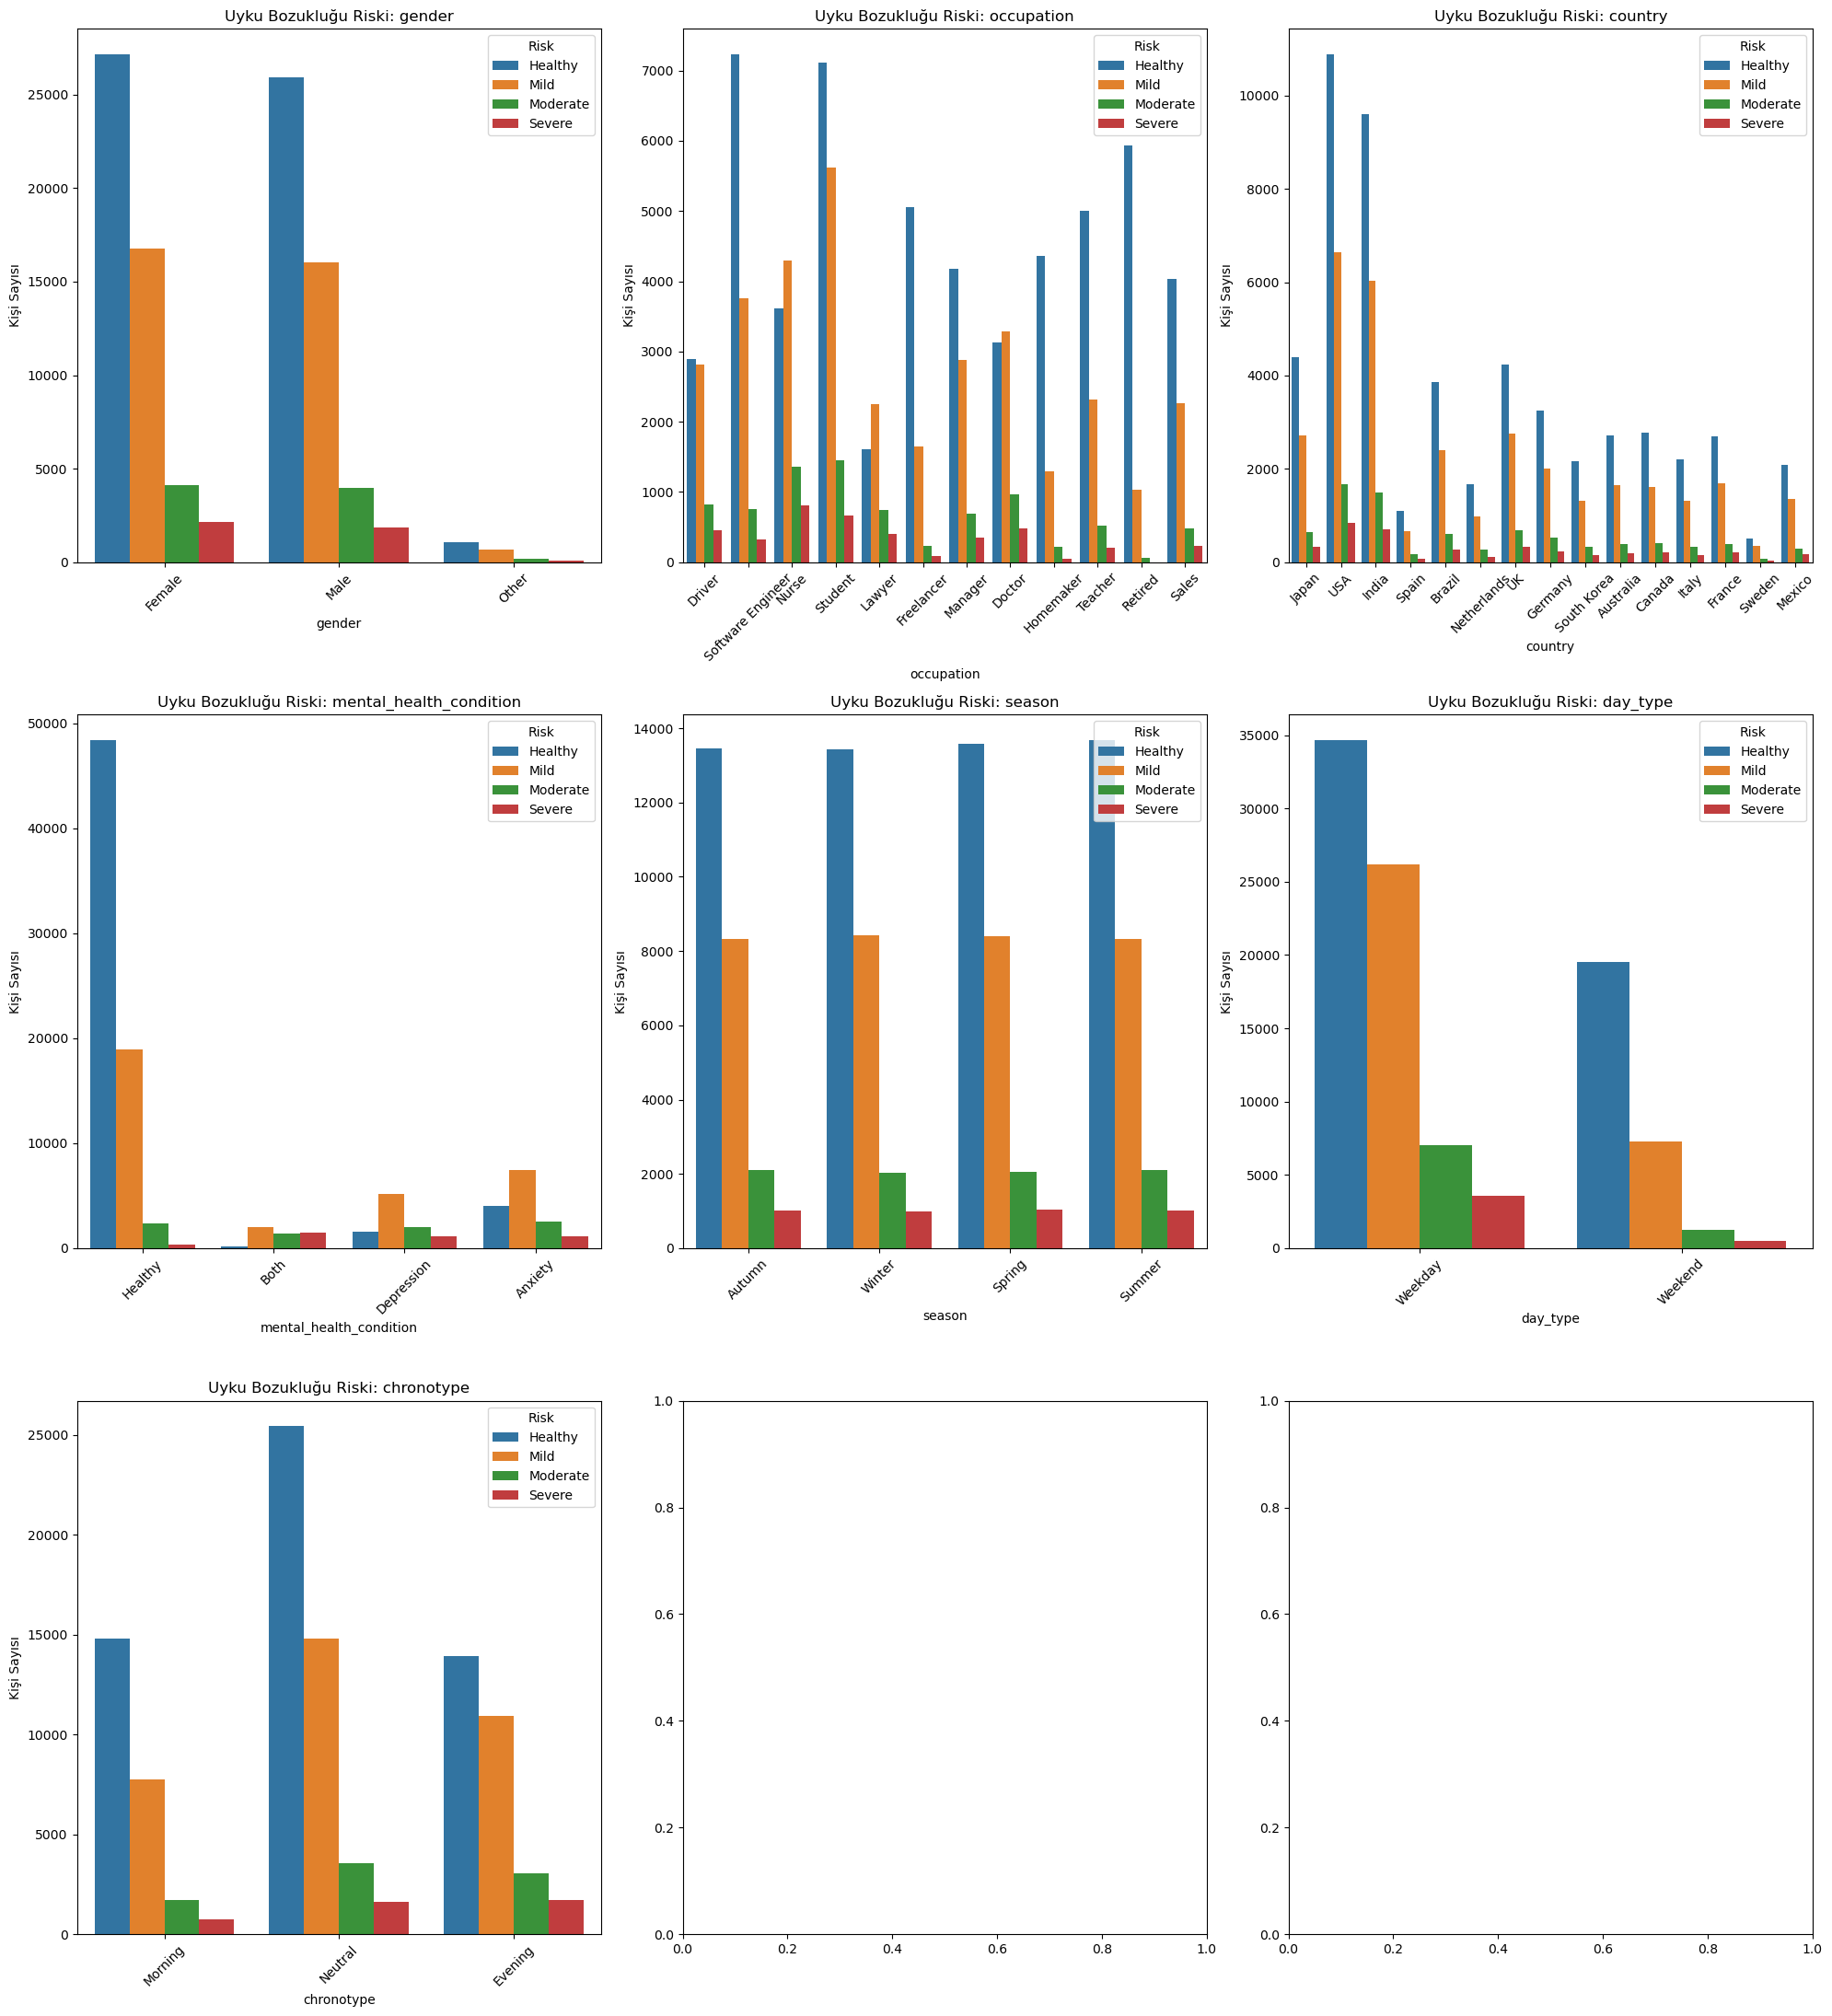

In [74]:
cat_cols = [
    "gender",
    "occupation",
    "country",
    "mental_health_condition",
    "season",
    "day_type",
    "chronotype"
]

fig, axes = plt.subplots(3, 3, figsize=(20, 22))
axes = axes.flatten()

risk_order = ['Healthy', 'Mild', 'Moderate', 'Severe']

for i, cat in enumerate(cat_cols):
    sns.countplot(
        data=df,
        x=cat,
        hue='sleep_disorder_risk',
        hue_order=risk_order,
        ax=axes[i]
    )

    axes[i].set_title("Uyku Bozukluğu Riski: " + cat)
    axes[i].set_xlabel(cat)
    axes[i].set_ylabel("Kişi Sayısı")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title="Risk")

plt.tight_layout()
plt.show()

In [75]:
le = LabelEncoder()
df_encoded = df.copy()

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

df_encoded['sleep_disorder_risk'] = le.fit_transform(df_encoded['sleep_disorder_risk'].astype(str))

mi_scores = mutual_info_classif(
    df_encoded[cat_cols],
    df_encoded['sleep_disorder_risk'],
    random_state=42
)

mi_df = pd.DataFrame({
    'Değişken': cat_cols,
    'MI_Skoru': mi_scores
}).sort_values('MI_Skoru', ascending=False).reset_index(drop=True)

print("Mutual Information Sonuçları")
display(mi_df)

Mutual Information Sonuçları


,Değişken,MI_Skoru
0,mental_health_condition,0.162087
1,occupation,0.049602
2,day_type,0.020487
3,chronotype,0.006974
4,season,0.002013
5,gender,0.000322
6,country,0.000132


In [76]:
df=df.drop(columns=['season','country','gender','chronotype'])

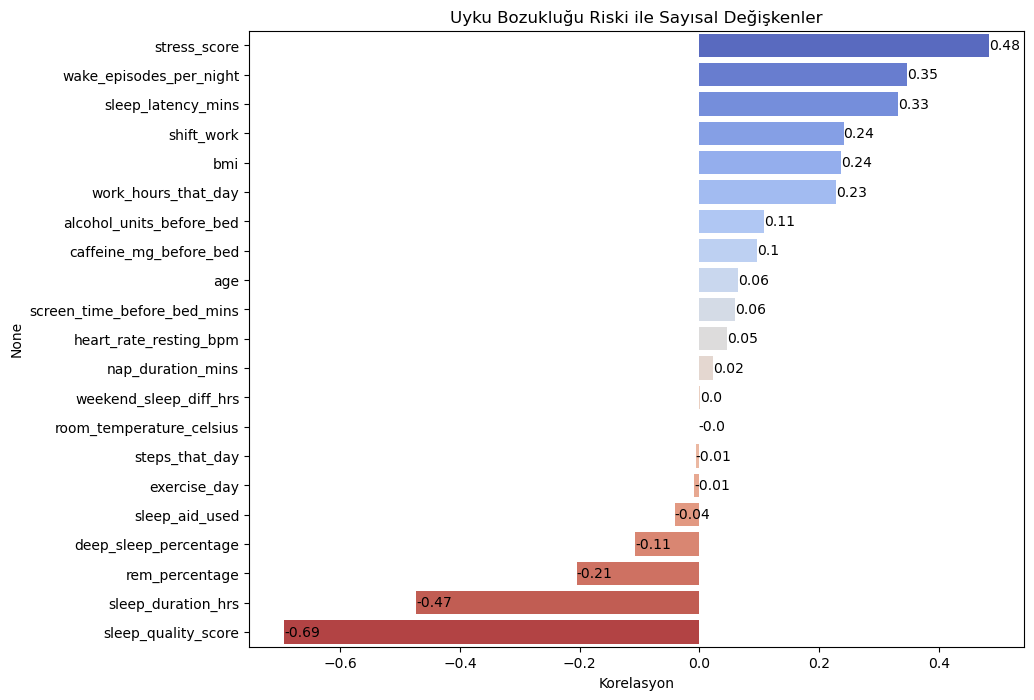

In [77]:
risk_mapping = {'Healthy': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}

df['sleep_disorder_risk'] = df['sleep_disorder_risk'].map(risk_mapping)

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

corr = df[num_cols].corr()['sleep_disorder_risk']

corr = corr.drop('sleep_disorder_risk')

corr = corr.sort_values(ascending=False)

plt.figure(figsize=(10,8))

sns.barplot(
    x=corr.values,
    y=corr.index,
    palette='coolwarm'
)

plt.title("Uyku Bozukluğu Riski ile Sayısal Değişkenler")
plt.xlabel("Korelasyon")

for i, v in enumerate(corr.values):
    plt.text(v, i, round(v, 2), va='center')

plt.show()

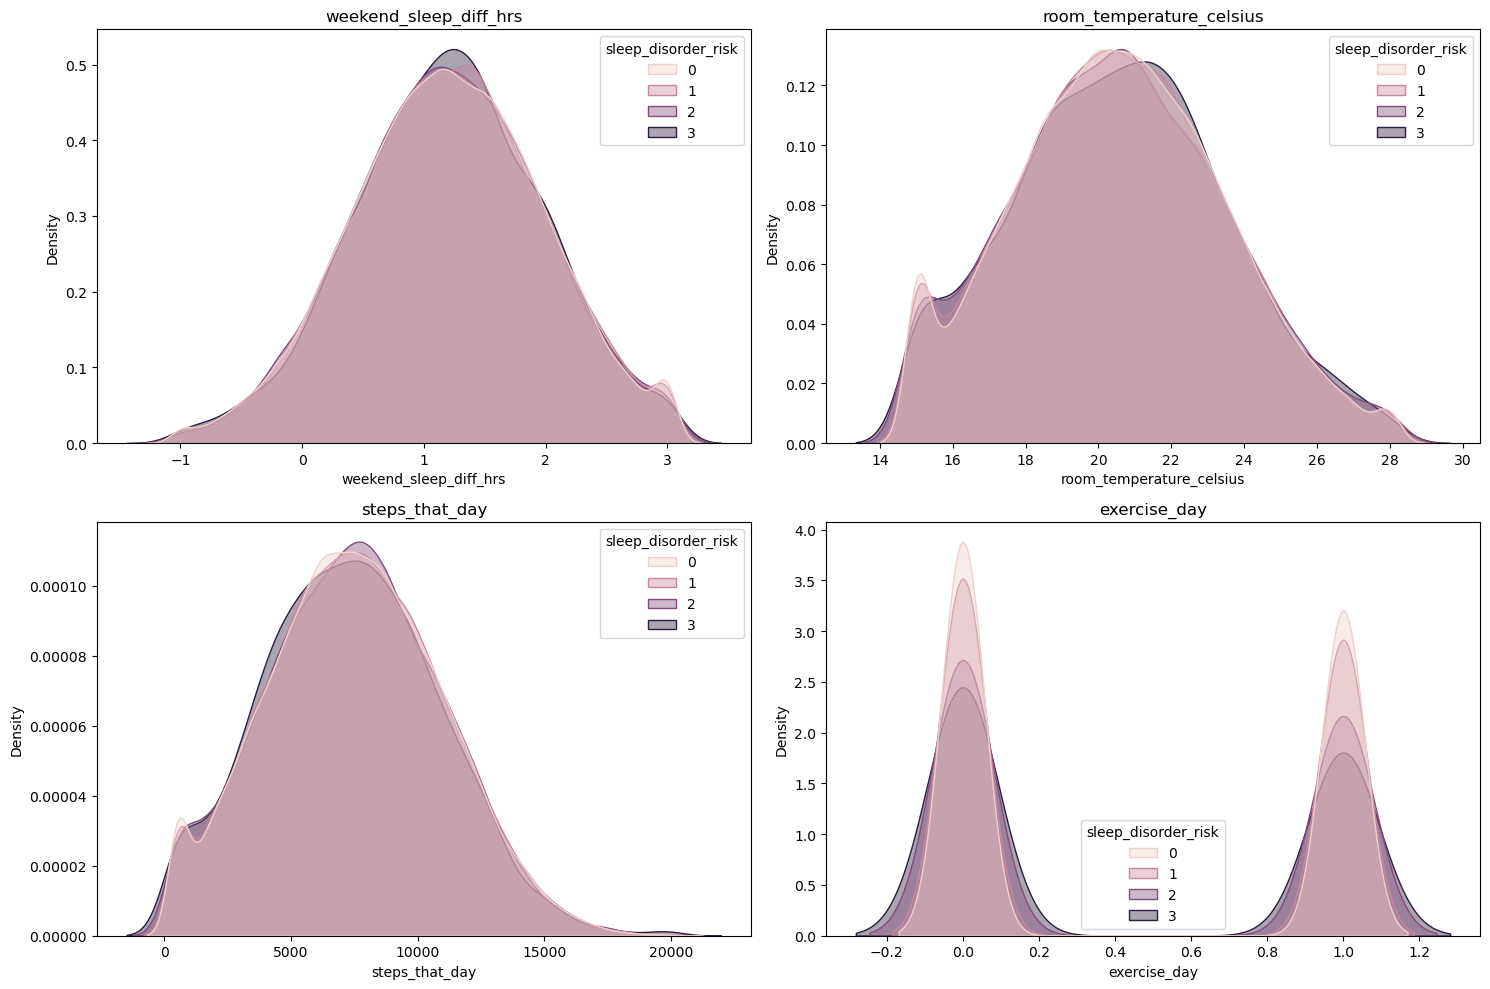

In [78]:
low_corr_cols = [
    'weekend_sleep_diff_hrs',
    'room_temperature_celsius',
    'steps_that_day',
    'exercise_day'
]

risk_order = ['Healthy', 'Mild', 'Moderate', 'Severe']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(low_corr_cols):
    sns.kdeplot(
        data=df,
        x=col,
        hue='sleep_disorder_risk',
        hue_order=risk_order,
        fill=True,
        common_norm=False,
        alpha=0.4,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

In [79]:
df = df.drop(columns=low_corr_cols)

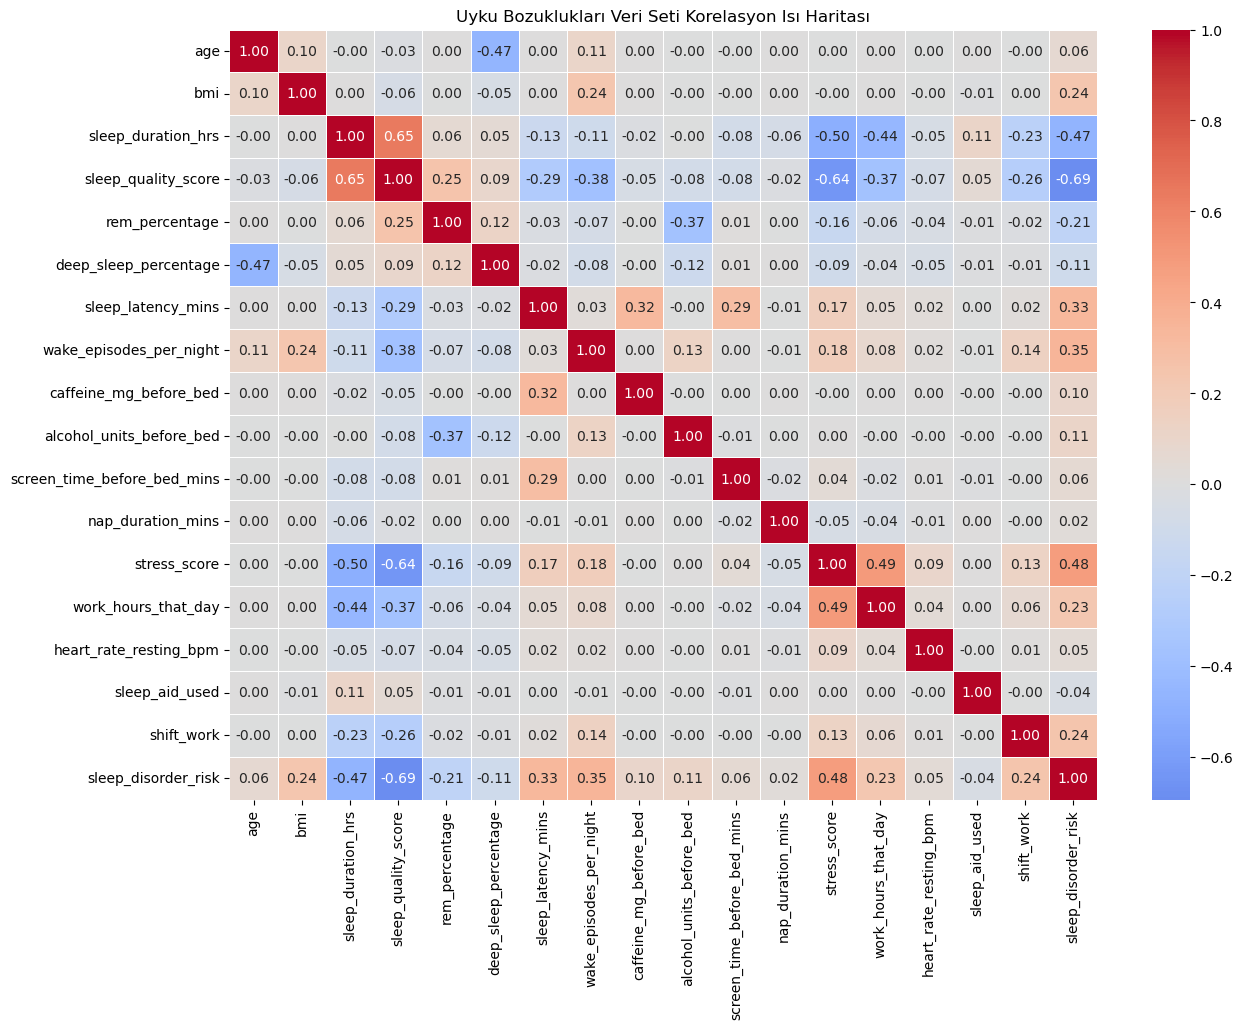

In [80]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, 
            annot=True,      
            fmt=".2f",       
            cmap='coolwarm', 
            linewidths=0.5, 
            center=0)        

plt.title('Uyku Bozuklukları Veri Seti Korelasyon Isı Haritası')
plt.show()

In [81]:
mental_mapping = {
    'Healthy': 0,
    'Anxiety': 1,
    'Depression': 1,
    'Both': 2
}

df['mental_health_condition'] = df['mental_health_condition'].map(mental_mapping)

df['day_type'] = df['day_type'].map({
    'Weekday': 0,
    'Weekend': 1
})

df = pd.get_dummies(
    df,
    columns=['occupation'],
    prefix='occ',
    dtype=int
)

print(df.shape)

df.head()

(100000, 32)


,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,...,occ_Freelancer,occ_Homemaker,occ_Lawyer,occ_Manager,occ_Nurse,occ_Retired,occ_Sales,occ_Software Engineer,occ_Student,occ_Teacher
0,29,25.7,6.19,6.6,22.5,19.3,16,3,0,0.0,...,0,0,0,0,0,0,0,0,0,0
1,55,22.0,8.32,6.9,26.9,14.9,17,4,0,0.0,...,0,0,0,0,0,0,0,1,0,0
2,42,25.0,3.74,1.0,20.2,16.2,26,4,0,2.0,...,0,0,0,0,1,0,0,0,0,0
3,37,29.5,6.79,6.4,17.7,17.7,13,4,0,1.0,...,0,0,0,0,0,0,0,0,1,0
4,23,23.6,5.02,3.2,23.3,18.3,30,5,40,0.0,...,0,0,1,0,0,0,0,0,0,0


In [82]:
x = df.drop(columns=['sleep_disorder_risk'])
y = df['sleep_disorder_risk']

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [83]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [84]:
sample_size = 10000
x_train_sample = x_train_scaled[:sample_size]
y_train_sample = y_train[:sample_size]

models = {
    "Lojistik Regresyon": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(x_train_sample, y_train_sample)
    pred = model.predict(x_test_scaled)
    
    acc = accuracy_score(y_test, pred)
    results.append({
        "Model": name, 
        "Accuracy": acc
    })

In [85]:
df_res = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
print(df_res)

                Model  Accuracy
3            LightGBM   0.91385
2             XGBoost   0.91200
6   Gradient Boosting   0.89135
1       Random Forest   0.86245
0  Lojistik Regresyon   0.81255
4                 KNN   0.70335
5         Naive Bayes   0.49325


In [86]:
param_dist = {
    'n_estimators': [100, 500, 1000, 2000],
    'learning_rate': [0.001, 0.01, 0.05, 0.1],
    'max_depth': [-1, 3, 5, 10, 15], 
    'num_leaves': [20, 31, 50, 100], 
    'subsample': [0.6, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.8, 0.9, 1.0],
    'min_child_samples': [10, 20, 50, 100]
}

In [87]:
lgbm_base = LGBMClassifier(random_state=42, verbose=-1)


search = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_dist,
    n_iter=15,
    scoring='accuracy',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)


search.fit(x_train_scaled, y_train)

best_lgbm_model = search.best_estimator_


print(search.best_params_)
print(search.best_score_)

pred = best_lgbm_model.predict(x_test_scaled)

print("Accuracy:", accuracy_score(y_test, pred))
print("Classification Report:", classification_report(y_test, pred))

Fitting 3 folds for each of 15 candidates, totalling 45 fits
{'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 20, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
0.9417249784190194
Accuracy: 0.94165
Classification Report:               precision    recall  f1-score   support

           0       0.99      0.99      0.99     10831
           1       0.92      0.95      0.93      6696
           2       0.74      0.68      0.71      1660
           3       0.86      0.78      0.82       813

    accuracy                           0.94     20000
   macro avg       0.88      0.85      0.86     20000
weighted avg       0.94      0.94      0.94     20000



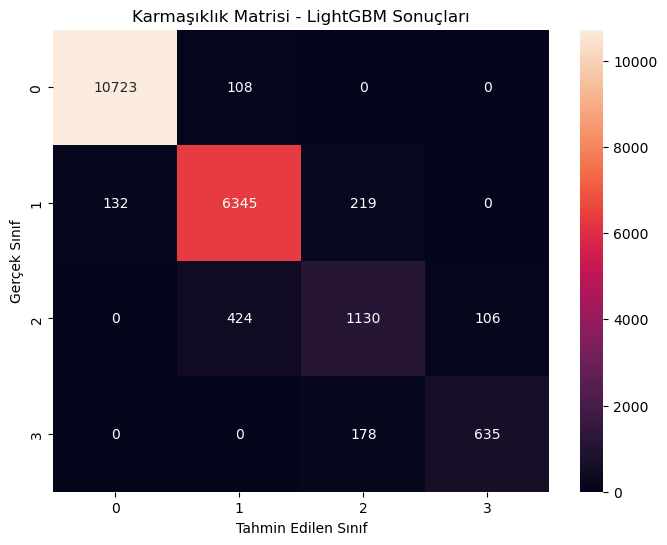

In [88]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True,      
            fmt='d',        
            xticklabels=best_lgbm_model.classes_, 
            yticklabels=best_lgbm_model.classes_)

plt.title('Karmaşıklık Matrisi - LightGBM Sonuçları')
plt.xlabel('Tahmin Edilen Sınıf')
plt.ylabel('Gerçek Sınıf')
plt.show()

In [89]:
joblib.dump(best_lgbm_model, "disorder_model.joblib")

model_columns = x.columns.tolist()
joblib.dump(model_columns, "disorder_model_columns.joblib")

joblib.dump(scaler, "disorder_scaler.joblib")

encoding_metadata = {
    "mental_mapping": {
        "Healthy": 0,
        "Anxiety": 1,
        "Depression": 1,
        "Both": 2
    },
    "day_type_mapping": {
        "Weekday": 0,
        "Weekend": 1
    },
    "is_one_hot_encoded": True,
    "encoded_prefix": "occ"
}

joblib.dump(
    encoding_metadata,
    "disorder_encoding.joblib"
)

['disorder_encoding.joblib']